In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import random
from torchvision import transforms
from PIL import Image
import re
import os

In [45]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [46]:
DATASET_DIR = "/kaggle/input/datasets/adityajn105/flickr8k"

IMAGE_DIR = os.path.join(DATASET_DIR, "Images")
CAPTION_FILE = os.path.join(DATASET_DIR, "captions.txt")

print("Image directory:", IMAGE_DIR)
print("Caption file:", CAPTION_FILE)

print("\nNumber of image files:",
      len(os.listdir(IMAGE_DIR)))

print("Caption file exists:",
      os.path.exists(CAPTION_FILE))

Image directory: /kaggle/input/datasets/adityajn105/flickr8k/Images
Caption file: /kaggle/input/datasets/adityajn105/flickr8k/captions.txt

Number of image files: 8091
Caption file exists: True


# Caption Preprocessing

In [47]:
captions_df = pd.read_csv(CAPTION_FILE)

print(captions_df.head(), "\n")
print(captions_df.shape, "\n")
print(captions_df.columns, "\n")

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...   

(40455, 2) 

Index(['image', 'caption'], dtype='object') 



In [48]:
caption_counts = captions_df.groupby("image")["caption"].count()

print(caption_counts.shape[0])
print((caption_counts != 5).sum())

8091
0


In [49]:
all_images = captions_df["image"].unique()

In [50]:
images = list(all_images)

random.shuffle(images)

num_images = len(images)

train_size = int(0.80 * num_images)
val_size = int(0.10 * num_images)

train_images = images[:train_size]
val_images = images[train_size:train_size + val_size]
test_images = images[train_size + val_size:]

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))
print("Total:", len(train_images) + len(val_images) + len(test_images))

Train images: 6472
Validation images: 809
Test images: 810
Total: 8091


In [51]:
train_set = set(train_images)
val_set = set(val_images)
test_set = set(test_images)

In [52]:
train_df = captions_df[captions_df["image"].isin(train_set)].copy()
val_df = captions_df[captions_df["image"].isin(val_set)].copy()
test_df = captions_df[captions_df["image"].isin(test_set)].copy()

print("Training caption pairs:", len(train_df))
print("Validation caption pairs:", len(val_df))
print("Test caption pairs:", len(test_df))

Training caption pairs: 32360
Validation caption pairs: 4045
Test caption pairs: 4050


## Caption Cleaning

In [53]:
def clean_caption(caption):
    caption = caption.lower()

    # Keep only letters and spaces
    caption = re.sub(r"[^a-z\s]", "", caption)

    # Remove extra spaces
    caption = re.sub(r"\s+", " ", caption).strip()

    return caption

In [54]:
example = captions_df.iloc[0]["caption"]

print("Original:")
print(example)

print("\nCleaned:")
print(clean_caption(example))

Original:
A child in a pink dress is climbing up a set of stairs in an entry way .

Cleaned:
a child in a pink dress is climbing up a set of stairs in an entry way


In [55]:
train_df["clean_caption"] = train_df["caption"].apply(clean_caption)
val_df["clean_caption"] = val_df["caption"].apply(clean_caption)
test_df["clean_caption"] = test_df["caption"].apply(clean_caption)

train_df.head()

,image,caption,clean_caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,a child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,a girl going into a wooden building
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,a little girl climbing into a wooden playhouse
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,a little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,a little girl in a pink dress going into a woo...


## Adding special tokens 

In [56]:
SPECIAL_TOKENS = ["<pad>", "<unk>", "<start>", "<end>"]

def add_special_tokens(caption):
    return f"<start> {caption} <end>"

In [57]:
train_df["processed_caption"] = train_df["clean_caption"].apply(add_special_tokens)
val_df["processed_caption"] = val_df["clean_caption"].apply(add_special_tokens)
test_df["processed_caption"] = test_df["clean_caption"].apply(add_special_tokens)

print(train_df.iloc[0]["processed_caption"])

<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>


## Now its time for tokenization

In [58]:
def tokenize(caption):
    return caption.split()

example_caption = train_df.iloc[0]["processed_caption"]

print(example_caption)
print(tokenize(example_caption))

<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>
['<start>', 'a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way', '<end>']


## Building vocab

In [59]:
from collections import Counter

word_counter = Counter()

for caption in train_df["processed_caption"]:
    tokens = tokenize(caption)
    word_counter.update(tokens)

print("Total unique tokens before rare-word filtering:",
      len(word_counter))

Total unique tokens before rare-word filtering: 7946


In [60]:
MIN_FREQ = 2

vocab_words = [
    word for word, count in word_counter.items()
    if count >= MIN_FREQ
]

print("Vocabulary words after rare-word filtering:",
      len(vocab_words))

Vocabulary words after rare-word filtering: 4675


In [61]:
word_to_idx = {}

for idx, token in enumerate(SPECIAL_TOKENS):
    word_to_idx[token] = idx

next_idx = len(word_to_idx)

for word in sorted(vocab_words):
    if word not in word_to_idx:
        word_to_idx[word] = next_idx
        next_idx += 1

print("First 20 entries:")
for word, idx in list(word_to_idx.items())[:20]:
    print(word, "=", idx)

First 20 entries:
<pad> = 0
<unk> = 1
<start> = 2
<end> = 3
a = 4
abandoned = 5
about = 6
above = 7
abseiling = 8
ac = 9
accented = 10
accident = 11
accompanied = 12
accordion = 13
acoustic = 14
acrobatic = 15
acrobatics = 16
across = 17
act = 18
acting = 19


index mapping is working, the first 4 are the special tokens

In [62]:
idx_to_word = {
    idx: word
    for word, idx in word_to_idx.items()
}

print(idx_to_word[:5] if isinstance(idx_to_word, list) else
      list(idx_to_word.items())[:5])

[(0, '<pad>'), (1, '<unk>'), (2, '<start>'), (3, '<end>'), (4, 'a')]


## Integer sequence

In [63]:
def caption_to_sequence(caption, word_to_idx):
    tokens = tokenize(caption)

    sequence = []

    for token in tokens:
        if token in word_to_idx:
            sequence.append(word_to_idx[token])
        else:
            sequence.append(word_to_idx["<unk>"])

    return sequence

In [64]:
example = train_df.iloc[0]["processed_caption"]

print("Caption:")
print(example)

sequence = caption_to_sequence(example, word_to_idx)

print("\nSequence:")
print(sequence)

Caption:
<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>

Sequence:
[2, 4, 756, 2026, 4, 2923, 1209, 2081, 807, 4398, 4, 3472, 2657, 3861, 2026, 89, 1, 4526, 3]


In [65]:
train_sequences = [
    caption_to_sequence(caption, word_to_idx)
    for caption in train_df["processed_caption"]
]

caption_lengths = [len(seq) for seq in train_sequences]

print("Maximum caption length:", max(caption_lengths))
print("Average caption length:", np.mean(caption_lengths))
print("95th percentile:", np.percentile(caption_lengths, 95))

Maximum caption length: 37
Average caption length: 12.767985166872682
95th percentile: 19.0


## Adding padding

In [66]:
MAX_LENGTH = max(caption_lengths)

In [67]:
PAD_IDX = word_to_idx["<pad>"]

def pad_sequence(sequence, max_length, pad_idx=PAD_IDX):
    if len(sequence) < max_length:
        sequence = sequence + [pad_idx] * (max_length - len(sequence))
    else:
        sequence = sequence[:max_length]

    return sequence
    
def process_caption(caption):
    sequence = caption_to_sequence(caption, word_to_idx)
    sequence = pad_sequence(sequence, MAX_LENGTH)

    return sequence

In [68]:
train_df["sequence"] = train_df["processed_caption"].apply(process_caption)
val_df["sequence"] = val_df["processed_caption"].apply(process_caption)
test_df["sequence"] = test_df["processed_caption"].apply(process_caption)

In [69]:
idx = 0

caption = train_df.iloc[idx]["processed_caption"]
sequence = train_df.iloc[idx]["sequence"]

print("Caption:")
print(caption)

print("\nNumerical sequence:")
print(sequence)

print("\nLength:")
print(len(sequence))

Caption:
<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>

Numerical sequence:
[2, 4, 756, 2026, 4, 2923, 1209, 2081, 807, 4398, 4, 3472, 2657, 3861, 2026, 89, 1, 4526, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Length:
37


0 = `<pad>` so that is correct

## Decoding

In [70]:
def sequence_to_caption(sequence, idx_to_word):
    words = []

    for idx in sequence:
        word = idx_to_word[int(idx)]

        if word == "<pad>":
            continue

        words.append(word)

        if word == "<end>":
            break

    return " ".join(words)

In [71]:
decoded = sequence_to_caption(
    train_df.iloc[0]["sequence"],
    idx_to_word
)

print(decoded)

<start> a child in a pink dress is climbing up a set of stairs in an <unk> way <end>


In [72]:
UNK_IDX = word_to_idx["<unk>"]

def count_unknowns(sequences):
    total = 0
    unknown = 0

    for sequence in sequences:
        for token in sequence:
            if token == PAD_IDX:
                continue

            total += 1

            if token == UNK_IDX:
                unknown += 1

    return unknown, total

train_unknown, train_total = count_unknowns(train_df["sequence"])
val_unknown, val_total = count_unknowns(val_df["sequence"])
test_unknown, test_total = count_unknowns(test_df["sequence"])

print("Train <unk> ratio:", train_unknown / train_total)
print("Validation <unk> ratio:", val_unknown / val_total)
print("Test <unk> ratio:", test_unknown / test_total)

Train <unk> ratio: 0.007916799783141162
Validation <unk> ratio: 0.015104286923728161
Test <unk> ratio: 0.015219560878243513


very good ratio 

## Image Preprocessing

i will use a pretrained resnet, so i will use the preprocessing expected by ImageNet-pretrained models (data taken from google)

In [73]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [74]:
sample_image_name = train_images[0]
sample_image_path = os.path.join(IMAGE_DIR, sample_image_name)

image = Image.open(sample_image_path).convert("RGB")

print("Original image size:", image.size)

image_tensor = image_transform(image)

print("Processed tensor shape:", image_tensor.shape)

Original image size: (500, 333)
Processed tensor shape: torch.Size([3, 224, 224])


# ResNet

In [75]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from tqdm.auto import tqdm

In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [77]:
weights = ResNet50_Weights.DEFAULT

resnet = resnet50(weights=weights)

print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [78]:
resnet.fc = nn.Identity()

print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## freezing ResNet parameters

In [79]:
for param in resnet.parameters():
    param.requires_grad = False

trainable_params = sum(
    p.numel()
    for p in resnet.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in resnet.parameters()
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 23508032
Trainable parameters: 0


In [80]:
resnet = resnet.to(device)
resnet.eval()

resnet = resnet.to(device)
resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [81]:
class FlickrImageDataset(Dataset):
    def __init__(self, image_names, image_dir, transform):
        self.image_names = image_names
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        image_path = os.path.join(self.image_dir, image_name)

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, image_name

In [82]:
train_image_dataset = FlickrImageDataset(
    train_images,
    IMAGE_DIR,
    image_transform
)

val_image_dataset = FlickrImageDataset(
    val_images,
    IMAGE_DIR,
    image_transform
)

test_image_dataset = FlickrImageDataset(
    test_images,
    IMAGE_DIR,
    image_transform
)

print("Train:", len(train_image_dataset))
print("Validation:", len(val_image_dataset))
print("Test:", len(test_image_dataset))

Train: 6472
Validation: 809
Test: 810


In [83]:
BATCH_SIZE = 64

train_image_loader = DataLoader(
    train_image_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

val_image_loader = DataLoader(
    val_image_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_image_loader = DataLoader(
    test_image_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

testing on one batch

In [84]:
images, image_names = next(iter(train_image_loader))

print("Image batch shape:", images.shape)
print("Number of filenames:", len(image_names))
print("First filename:", image_names[0])

Image batch shape: torch.Size([64, 3, 224, 224])
Number of filenames: 64
First filename: 2874984466_1aafec2c9f.jpg


In [85]:
images = images.to(device)

with torch.no_grad():
    features = resnet(images)

print("Feature shape:", features.shape)

Feature shape: torch.Size([64, 2048])


In [86]:
FEATURE_DIR = "/kaggle/working/flickr8k_features"

TRAIN_FEATURE_DIR = os.path.join(FEATURE_DIR, "train")
VAL_FEATURE_DIR = os.path.join(FEATURE_DIR, "val")
TEST_FEATURE_DIR = os.path.join(FEATURE_DIR, "test")

os.makedirs(TRAIN_FEATURE_DIR, exist_ok=True)
os.makedirs(VAL_FEATURE_DIR, exist_ok=True)
os.makedirs(TEST_FEATURE_DIR, exist_ok=True)

## Feature extraction

In [87]:
def extract_features(dataloader, output_dir, model, device):
    model.eval()

    for images, image_names in tqdm(dataloader):
        images = images.to(device)

        with torch.no_grad():
            features = model(images)

        features = features.cpu()

        for feature, image_name in zip(features, image_names):
            filename = os.path.splitext(image_name)[0] + ".pt"
            save_path = os.path.join(output_dir, filename)

            torch.save(feature, save_path)

In [88]:
extract_features(
    train_image_loader,
    TRAIN_FEATURE_DIR,
    resnet,
    device
)

  0%|          | 0/102 [00:00<?, ?it/s]

In [89]:
extract_features(
    val_image_loader,
    VAL_FEATURE_DIR,
    resnet,
    device
)

  0%|          | 0/13 [00:00<?, ?it/s]

In [90]:
extract_features(
    test_image_loader,
    TEST_FEATURE_DIR,
    resnet,
    device
)

  0%|          | 0/13 [00:00<?, ?it/s]

In [91]:
train_feature_files = os.listdir(TRAIN_FEATURE_DIR)
val_feature_files = os.listdir(VAL_FEATURE_DIR)
test_feature_files = os.listdir(TEST_FEATURE_DIR)

print("Train feature files:", len(train_feature_files))
print("Validation feature files:", len(val_feature_files))
print("Test feature files:", len(test_feature_files))

Train feature files: 6472
Validation feature files: 809
Test feature files: 810


In [92]:
sample_row = train_df.iloc[0]

image_name = sample_row["image"]
caption_sequence = sample_row["sequence"]

feature_filename = os.path.splitext(image_name)[0] + ".pt"

feature = torch.load(
    os.path.join(TRAIN_FEATURE_DIR, feature_filename),
    weights_only=True
)

print("Image:", image_name)
print("Feature shape:", feature.shape)
print("Caption sequence:", caption_sequence)

Image: 1000268201_693b08cb0e.jpg
Feature shape: torch.Size([2048])
Caption sequence: [2, 4, 756, 2026, 4, 2923, 1209, 2081, 807, 4398, 4, 3472, 2657, 3861, 2026, 89, 1, 4526, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


now I have the exact pair that the captioning model will eventually use (Image feature + caption)

In [93]:
class CaptionDataset(Dataset):
    def __init__(self, dataframe, feature_dir, augment=False, noise_std=0.05):
        self.dataframe = dataframe.reset_index(drop=True)
        self.feature_dir = feature_dir

        # The ResNet features are extracted once and cached to disk, so
        # without augmentation the model sees the *identical* feature
        # vector for a given image on every single epoch. That removes
        # the usual source of input noise that keeps a model from just
        # memorizing image -> caption pairs. Adding small Gaussian noise
        # to the cached feature (train split only) cheaply restores some
        # of that regularizing effect.
        self.augment = augment
        self.noise_std = noise_std

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_name = row["image"]
        caption = row["sequence"]

        # Get the corresponding cached ResNet feature
        feature_filename = os.path.splitext(image_name)[0] + ".pt"
        feature_path = os.path.join(
            self.feature_dir,
            feature_filename
        )

        image_feature = torch.load(
            feature_path,
            weights_only=True
        )

        if self.augment:
            image_feature = image_feature + torch.randn_like(image_feature) * self.noise_std

        caption = torch.tensor(
            caption,
            dtype=torch.long
        )

        # Teacher forcing:
        # Input  = everything except the last token
        # Target = everything except the first token
        input_caption = caption[:-1]
        target_caption = caption[1:]

        return image_feature, input_caption, target_caption

In [94]:
train_dataset = CaptionDataset(
    train_df,
    TRAIN_FEATURE_DIR,
    augment=True  # only the training split gets feature noise
)

val_dataset = CaptionDataset(
    val_df,
    VAL_FEATURE_DIR
)

test_dataset = CaptionDataset(
    test_df,
    TEST_FEATURE_DIR
)

In [95]:
image_feature, input_caption, target_caption = train_dataset[0]

print("INPUT:")
print(sequence_to_caption(
    input_caption.tolist(),
    idx_to_word
))

print("\nTARGET:")
print(sequence_to_caption(
    target_caption.tolist(),
    idx_to_word
))

INPUT:
<start> a child in a pink dress is climbing up a set of stairs in an <unk> way <end>

TARGET:
a child in a pink dress is climbing up a set of stairs in an <unk> way <end>


note: every sequence has already been padded to the same MAX_LENGTH

In [96]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [97]:
image_features, input_captions, target_captions = next(
    iter(train_loader)
)

In [98]:
image_features = image_features.to(device)
input_captions = input_captions.to(device)
target_captions = target_captions.to(device)

# Caption Generation Model

In [104]:
EMBED_SIZE = 256
HIDDEN_SIZE = 256
NUM_LAYERS = 1
DROPOUT = 0.4
VOCAB_SIZE = len(word_to_idx)

In [100]:
class ImageEncoder(nn.Module):
    def __init__(self, input_size=2048, hidden_size=512, dropout=0.3):
        super().__init__()

        self.fc = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, image_features):
        features = self.fc(image_features)
        features = self.relu(features)
        features = self.dropout(features)

        return features

In [101]:
encoder = ImageEncoder(
    input_size=2048,
    hidden_size=HIDDEN_SIZE,
    dropout=DROPOUT
)

encoder = encoder.to(device)

print(encoder)

ImageEncoder(
  (fc): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (relu): ReLU()
)


In [102]:
class CaptionDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_size=256,
        hidden_size=256,
        num_layers=1,
        dropout=0.4,
        pad_idx=0
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Convert word IDs → dense vectors
        self.embedding = nn.Embedding(
            vocab_size,
            embed_size,
            padding_idx=pad_idx
        )

        # Dropout applied directly to the embeddings. Without this,
        # the embedding table is free to memorize frequent word
        # sequences from the (fairly repetitive) training captions,
        # which was a big driver of the overfitting we saw.
        self.embedding_dropout = nn.Dropout(dropout)

        # LSTM processes the caption sequence
        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Hidden state → vocabulary scores
        self.fc = nn.Linear(
            hidden_size,
            vocab_size
        )

        self.dropout = nn.Dropout(dropout)

        # Convert image representation into
        # the initial LSTM cell state
        self.image_to_cell = nn.Linear(
            hidden_size,
            hidden_size
        )

    def forward(self, image_features, captions):

        # Convert token IDs to embeddings
        embeddings = self.embedding(captions)
        embeddings = self.embedding_dropout(embeddings)

        # Create initial hidden state from image
        hidden_state = image_features.unsqueeze(0)

        # Create initial cell state from image
        cell_state = self.image_to_cell(image_features)
        cell_state = cell_state.unsqueeze(0)

        # Run the sequence through the LSTM
        lstm_output, _ = self.lstm(
            embeddings,
            (hidden_state, cell_state)
        )

        lstm_output = self.dropout(lstm_output)

        # Predict vocabulary distribution
        outputs = self.fc(lstm_output)

        return outputs

In [105]:
decoder = CaptionDecoder(
    vocab_size=VOCAB_SIZE,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX
)

decoder = decoder.to(device)

print(decoder)

CaptionDecoder(
  (embedding): Embedding(4677, 256, padding_idx=0)
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (lstm): LSTM(256, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=4677, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (image_to_cell): Linear(in_features=256, out_features=256, bias=True)
)


combining both encoder and decoder into one model

In [106]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, image_features, captions):

        encoded_features = self.encoder(image_features)

        outputs = self.decoder(
            encoded_features,
            captions
        )

        return outputs

In [107]:
model = ImageCaptioningModel(
    encoder,
    decoder
)

model = model.to(device)

print(model)

ImageCaptioningModel(
  (encoder): ImageEncoder(
    (fc): Linear(in_features=2048, out_features=256, bias=True)
    (dropout): Dropout(p=0.4, inplace=False)
    (relu): ReLU()
  )
  (decoder): CaptionDecoder(
    (embedding): Embedding(4677, 256, padding_idx=0)
    (embedding_dropout): Dropout(p=0.4, inplace=False)
    (lstm): LSTM(256, 256, batch_first=True)
    (fc): Linear(in_features=256, out_features=4677, bias=True)
    (dropout): Dropout(p=0.4, inplace=False)
    (image_to_cell): Linear(in_features=256, out_features=256, bias=True)
  )
)


In [108]:
image_features, input_captions, target_captions = next(
    iter(train_loader)
)

image_features = image_features.to(device)
input_captions = input_captions.to(device)
target_captions = target_captions.to(device)

with torch.no_grad():
    outputs = model(
        image_features,
        input_captions
    )

# Model Training

In [109]:
import torch.optim as optim

# Ignore <pad> tokens when calculating the loss.
# label_smoothing softens the training targets so the model isn't pushed
# to be maximally (over)confident about the exact next word, which was
# part of why training loss kept dropping while validation loss rose.
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX,
    label_smoothing=0.1
)

optimizer = optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4  # increased from 1e-5 for stronger regularization
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [110]:
NUM_EPOCHS = 20

EARLY_STOPPING_PATIENCE = 4

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_caption_model.pth"
)

In [111]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()

    total_loss = 0

    for image_features, input_captions, target_captions in tqdm(
        dataloader,
        desc="Training"
    ):
        image_features = image_features.to(device)
        input_captions = input_captions.to(device)
        target_captions = target_captions.to(device)

        optimizer.zero_grad()

        outputs = model(
            image_features,
            input_captions
        )

        outputs = outputs.reshape(
            -1,
            outputs.size(-1)
        )

        targets = target_captions.reshape(-1)

        loss = criterion(outputs, targets)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [112]:
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0

    with torch.no_grad():
        for image_features, input_captions, target_captions in tqdm(
            dataloader,
            desc="Validation"
        ):
            image_features = image_features.to(device)
            input_captions = input_captions.to(device)
            target_captions = target_captions.to(device)

            outputs = model(
                image_features,
                input_captions
            )

            outputs = outputs.reshape(
                -1,
                outputs.size(-1)
            )

            targets = target_captions.reshape(-1)

            loss = criterion(outputs, targets)

            total_loss += loss.item()

    return total_loss / len(dataloader)

In [113]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 40)

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Training loss:   {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")

    # Learning-rate scheduler
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Learning rate:    {current_lr:.6f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "vocab_size": VOCAB_SIZE,
            "embed_size": EMBED_SIZE,
            "hidden_size": HIDDEN_SIZE,
            "max_length": MAX_LENGTH,
            "word_to_idx": word_to_idx,
            "idx_to_word": idx_to_word
        }, BEST_MODEL_PATH)

        print("Best model saved.")

    else:
        epochs_without_improvement += 1
        print(
            f"No improvement for "
            f"{epochs_without_improvement} epoch(s)."
        )

    # Early stopping
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping triggered.")
        break


Epoch 1/20
----------------------------------------


Training:   0%|          | 0/506 [00:00<?, ?it/s]

Validation:   0%|          | 0/64 [00:00<?, ?it/s]

Training loss:   5.3996
Validation loss: 4.7441
Learning rate:    0.000300
Best model saved.

Epoch 2/20
----------------------------------------


Training:   0%|          | 0/506 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/64 [00:00<?, ?it/s]

Training loss:   3.7410
Validation loss: 3.7607
Learning rate:    0.000300
Best model saved.

Epoch 20/20
----------------------------------------


Training:   0%|          | 0/506 [00:00<?, ?it/s]

Validation:   0%|          | 0/64 [00:00<?, ?it/s]

Training loss:   3.7271
Validation loss: 3.7508
Learning rate:    0.000300
Best model saved.


# Evaluation

In [114]:
!pip install -q nltk rouge-score

In [115]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("punkt_tab") #need them for METEOR

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [116]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}")
print(f"Validation loss at that epoch: {checkpoint['val_loss']:.4f}")

Loaded best checkpoint from epoch 20
Validation loss at that epoch: 3.7508


In [118]:
def generate_caption(model, image_feature, word_to_idx, idx_to_word, max_length, device):
    model.eval()
    encoder = model.encoder
    decoder = model.decoder

    start_idx = word_to_idx["<start>"]
    end_idx = word_to_idx["<end>"]

    with torch.no_grad():
        image_feature = image_feature.unsqueeze(0).to(device)   # (1, 2048)
        encoded = encoder(image_feature)                        # (1, hidden_size)

        hidden = encoded.unsqueeze(0)                           # (1, 1, hidden_size)
        cell = decoder.image_to_cell(encoded).unsqueeze(0)      # (1, 1, hidden_size)

        input_token = torch.tensor([[start_idx]], device=device)
        generated_ids = []

        for _ in range(max_length):
            embedded = decoder.embedding(input_token)
            if hasattr(decoder, "embedding_dropout"):
                embedded = decoder.embedding_dropout(embedded)

            lstm_out, (hidden, cell) = decoder.lstm(embedded, (hidden, cell))
            logits = decoder.fc(lstm_out.squeeze(1))

            next_id = logits.argmax(dim=-1).item()
            if next_id == end_idx:
                break

            generated_ids.append(next_id)
            input_token = torch.tensor([[next_id]], device=device)

    return " ".join(idx_to_word[idx] for idx in generated_ids)

In [119]:
test_references = (
    test_df.groupby("image")["clean_caption"]
    .apply(list)
    .to_dict()
)

print(f"Number of unique test images: {len(test_references)}")
print("Example:", list(test_references.items())[0])

Number of unique test images: 810
Example: ('1003163366_44323f5815.jpg', ['a man lays on a bench while his dog sits by him', 'a man lays on the bench to which a white dog is also tied', 'a man sleeping on a bench outside with a white and black dog sitting next to him', 'a shirtless man lies on a park bench with his dog', 'man laying on bench holding leash of dog sitting on ground'])


generating a caption for every test image

In [120]:
hypotheses = {}

for image_name in tqdm(test_references.keys(), desc="Generating captions"):
    feature_filename = os.path.splitext(image_name)[0] + ".pt"
    feature_path = os.path.join(TEST_FEATURE_DIR, feature_filename)

    image_feature = torch.load(feature_path, weights_only=True)

    hypotheses[image_name] = generate_caption(
        model, image_feature, word_to_idx, idx_to_word, MAX_LENGTH, device
    )

print(f"Generated {len(hypotheses)} captions")

Generating captions:   0%|          | 0/810 [00:00<?, ?it/s]

Generated 810 captions


## BLEU-1 through BLEU-4

In [121]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smoothie = SmoothingFunction().method4

list_of_references = [
    [ref.split() for ref in test_references[img]] for img in test_references
]
list_of_hypotheses = [hypotheses[img].split() for img in test_references]

bleu1 = corpus_bleu(list_of_references, list_of_hypotheses, weights=(1, 0, 0, 0), smoothing_function=smoothie)
bleu2 = corpus_bleu(list_of_references, list_of_hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
bleu3 = corpus_bleu(list_of_references, list_of_hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie)
bleu4 = corpus_bleu(list_of_references, list_of_hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)

print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-2: {bleu2:.4f}")
print(f"BLEU-3: {bleu3:.4f}")
print(f"BLEU-4: {bleu4:.4f}")

BLEU-1: 0.5734
BLEU-2: 0.3971
BLEU-3: 0.2621
BLEU-4: 0.1696


## ROUGE-L

In [122]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

rouge_l_scores = [
    max(scorer.score(ref, hypotheses[img])["rougeL"].fmeasure for ref in test_references[img])
    for img in test_references
]

avg_rouge_l = sum(rouge_l_scores) / len(rouge_l_scores)
print(f"ROUGE-L (F1, best-of-5 refs, averaged): {avg_rouge_l:.4f}")

ROUGE-L (F1, best-of-5 refs, averaged): 0.4427


## METEOR

In [123]:
from nltk.translate.meteor_score import meteor_score

meteor_scores = [
    meteor_score([ref.split() for ref in test_references[img]], hypotheses[img].split())
    for img in test_references
]

avg_meteor = sum(meteor_scores) / len(meteor_scores)
print(f"METEOR (averaged): {avg_meteor:.4f}")

METEOR (averaged): 0.3898


Final

In [124]:
import json

evaluation_results = {
    "BLEU-1": bleu1, "BLEU-2": bleu2, "BLEU-3": bleu3, "BLEU-4": bleu4,
    "ROUGE-L": avg_rouge_l, "METEOR": avg_meteor,
}

for metric, value in evaluation_results.items():
    print(f"{metric}: {value:.4f}")

with open("/kaggle/working/evaluation_results.json", "w") as f:
    json.dump(evaluation_results, f, indent=2)

BLEU-1: 0.5734
BLEU-2: 0.3971
BLEU-3: 0.2621
BLEU-4: 0.1696
ROUGE-L: 0.4427
METEOR: 0.3898


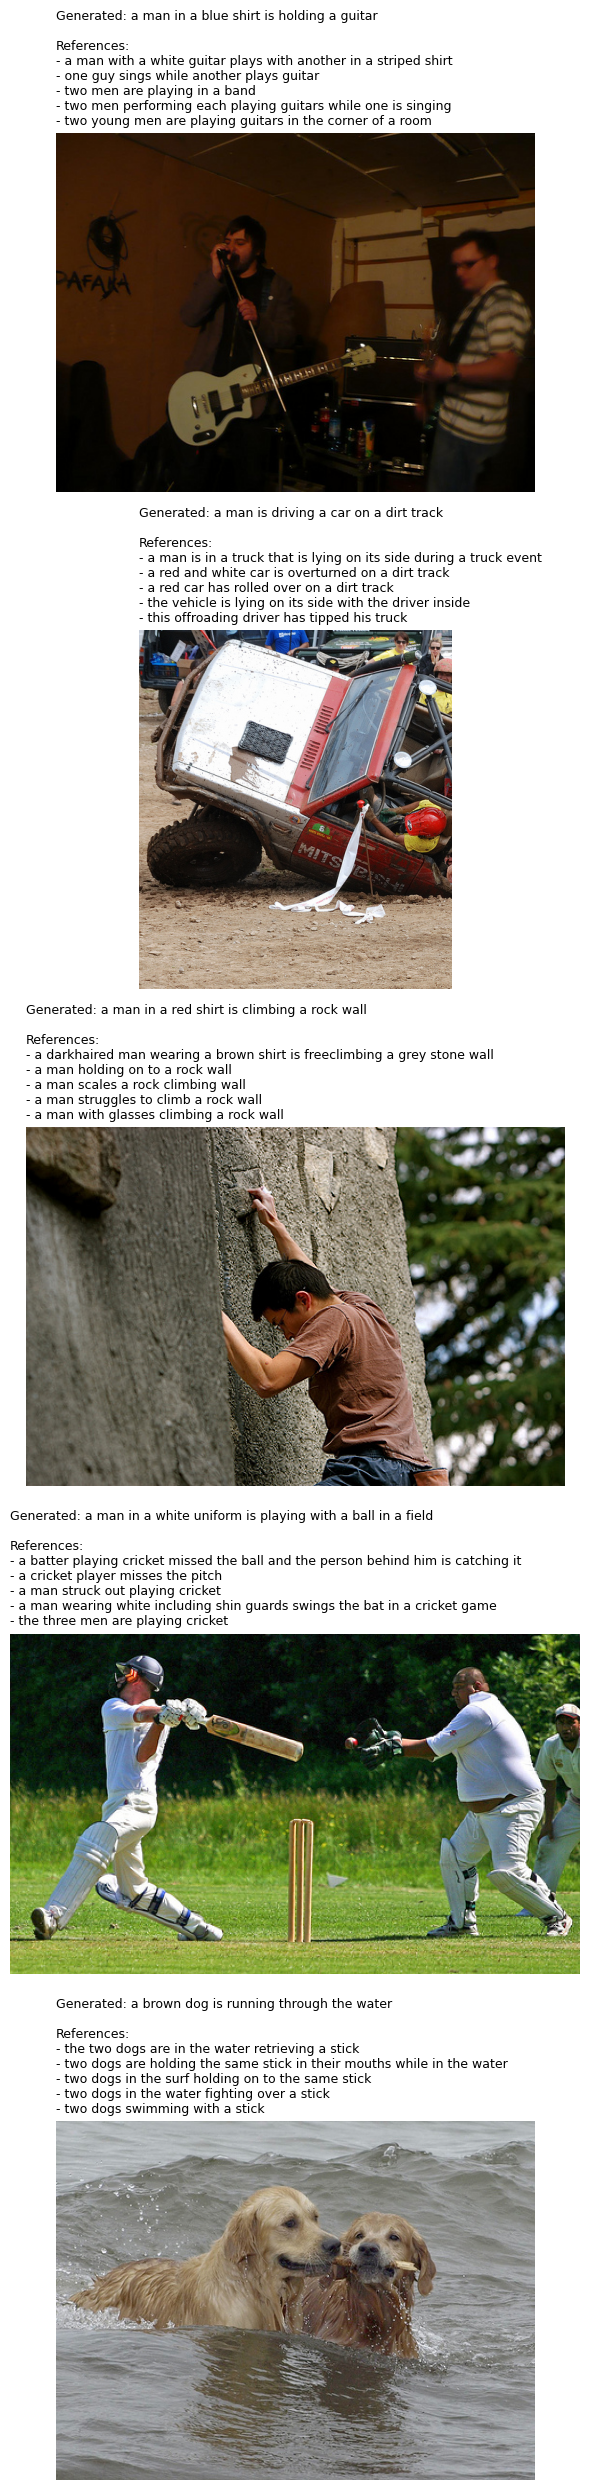

In [125]:
import matplotlib.pyplot as plt
import random

sample_images = random.sample(list(test_references.keys()), 5)
fig, axes = plt.subplots(len(sample_images), 1, figsize=(6, 5 * len(sample_images)))

for ax, image_name in zip(axes, sample_images):
    image = Image.open(os.path.join(IMAGE_DIR, image_name)).convert("RGB")
    ax.imshow(image)
    ax.axis("off")

    refs = "\n".join(f"- {r}" for r in test_references[image_name])
    ax.set_title(f"Generated: {hypotheses[image_name]}\n\nReferences:\n{refs}", fontsize=9, loc="left")

plt.tight_layout()
plt.show()